In [1]:
import pandas as pd




In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/raw/online_retail.csv", encoding="ISO-8859-1")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df = df.dropna(subset=["CustomerID"])


In [7]:
df.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].min(), df["InvoiceDate"].max()


(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

C:\Users\sowmy\AppData\Local\Temp\ipykernel_964\1760627623.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index("InvoiceDate").resample("M").size().plot(figsize=(10,4))


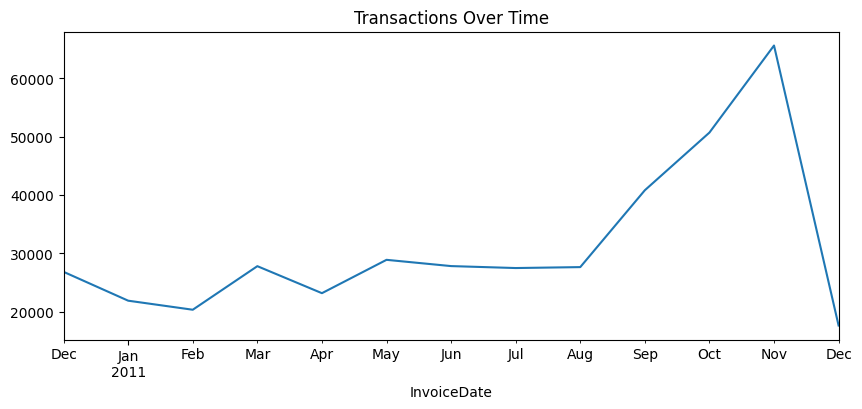

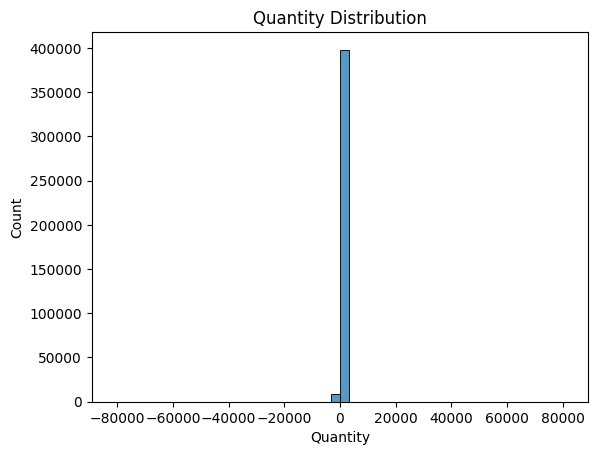

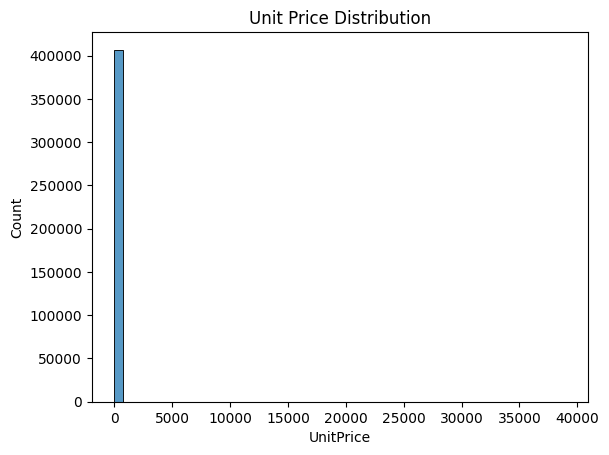

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transactions over time
df.set_index("InvoiceDate").resample("M").size().plot(figsize=(10,4))
plt.title("Transactions Over Time")
plt.show()

# Quantity distribution
sns.histplot(df["Quantity"], bins=50)
plt.title("Quantity Distribution")
plt.show()

# Unit price distribution
sns.histplot(df["UnitPrice"], bins=50)
plt.title("Unit Price Distribution")
plt.show()


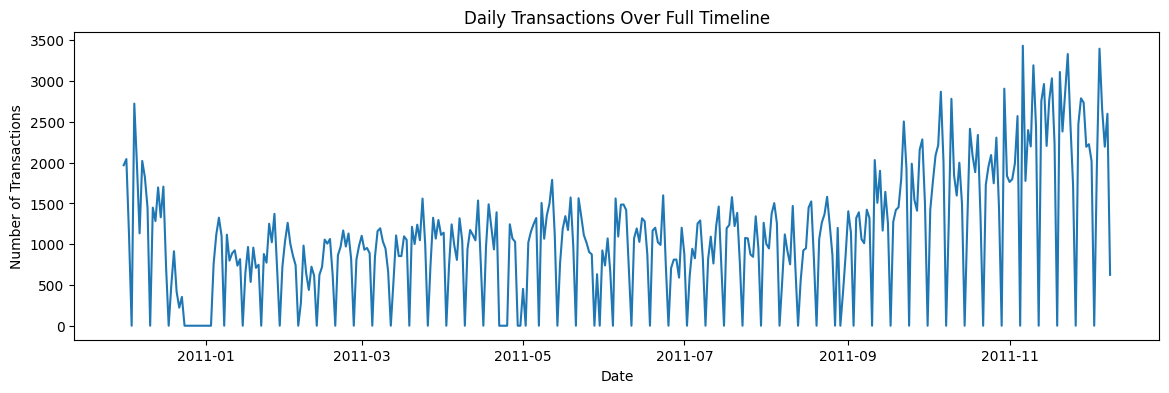

In [10]:
daily_txn = (
    df
    .set_index("InvoiceDate")
    .resample("D")
    .size()
)

plt.figure(figsize=(14,4))
plt.plot(daily_txn)
plt.title("Daily Transactions Over Full Timeline")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.show()


C:\Users\sowmy\AppData\Local\Temp\ipykernel_964\1981067257.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


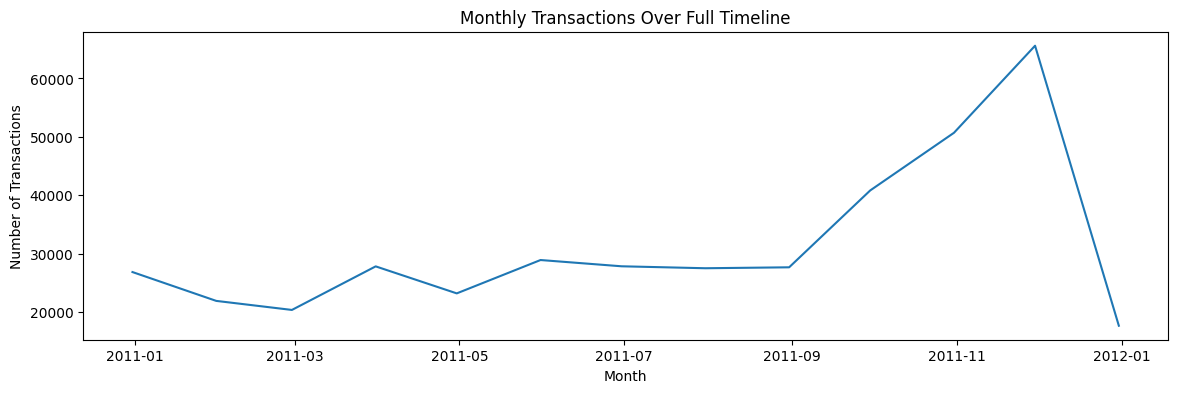

In [11]:
monthly_txn = (
    df
    .set_index("InvoiceDate")
    .resample("M")
    .size()
)

plt.figure(figsize=(14,4))
plt.plot(monthly_txn)
plt.title("Monthly Transactions Over Full Timeline")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()
